# 01 — EDA on processed parquet data

Goal: validate the 5 processed parquet files before building features. We're answering:

1. What's the shape and date coverage of each table?
2. Are the keys/grains what we expect, and do the tables join cleanly?
3. Is the win target (`official_finish == 1`) clean?
4. Are candidate features (odds, speed ratings, PP figures) usable?

Findings get summarized at the bottom and feed directly into `model/features.py`.

In [1]:
from pathlib import Path

import plotly.express as px
import polars as pl

pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_rows(20)

DATA_DIR = Path("../data/processed")

results = pl.read_parquet(DATA_DIR / "results.parquet")
entries = pl.read_parquet(DATA_DIR / "entries.parquet")
pps = pl.read_parquet(DATA_DIR / "past_performances.parquet")
workouts = pl.read_parquet(DATA_DIR / "workouts.parquet")
_all_tracks = pl.read_parquet(DATA_DIR / "track_codes.parquet")
tracks = _all_tracks.filter(pl.col("country").is_in(["USA", "CAN", "PR"]))

# only need

tables = {
    "results": results,
    "entries": entries,
    "past_performances": pps,
    "workouts": workouts,
    "tracks": tracks,
    "_all_track_codes": _all_tracks,
}
{name: df.shape for name, df in tables.items()}

{'results': (318702, 58),
 'entries': (472633, 34),
 'past_performances': (3469904, 26),
 'workouts': (954596, 13),
 'tracks': (233, 4),
 '_all_track_codes': (1614, 4)}

## 1. Shape and coverage

In [2]:
results.schema

Schema([('race_id', String),
        ('race_date', String),
        ('track', String),
        ('race_number', Int64),
        ('breed', String),
        ('race_type', String),
        ('purse', Float64),
        ('distance', Int64),
        ('distance_unit', String),
        ('surface', String),
        ('track_condition', String),
        ('weather', String),
        ('class_rating', Int64),
        ('num_runners', Int64),
        ('win_time', String),
        ('fraction_1', Float64),
        ('fraction_2', Float64),
        ('fraction_3', Float64),
        ('fraction_4', Float64),
        ('fraction_5', Float64),
        ('pace_call_1', String),
        ('pace_call_2', String),
        ('pace_final', String),
        ('footnotes', String),
        ('horse_name', String),
        ('program_number', String),
        ('post_position', Int64),
        ('weight', Int64),
        ('age', Int64),
        ('sex', String),
        ('medication', String),
        ('equipment', String),
      

In [3]:
entries.schema

Schema([('race_id', String),
        ('race_date', String),
        ('track', String),
        ('race_number', Int64),
        ('breed', String),
        ('race_type', String),
        ('race_type_desc', String),
        ('surface', String),
        ('distance_id', Int64),
        ('distance_published', String),
        ('purse', Float64),
        ('grade', String),
        ('num_runners', Int64),
        ('condition_text', String),
        ('max_claim_price', Float64),
        ('age_restriction', String),
        ('sex_restriction', String),
        ('horse_name', String),
        ('registration_number', String),
        ('year_of_birth', Int64),
        ('sex', String),
        ('post_position', Int64),
        ('program_number', String),
        ('morning_line_odds', String),
        ('morning_line_decimal', Float64),
        ('weight_carried', Int64),
        ('jockey_first_name', String),
        ('jockey_last_name', String),
        ('trainer_first_name', String),
        ('train

In [4]:
pps.schema

Schema([('race_id', String),
        ('horse_name', String),
        ('registration_number', String),
        ('pp_index', Int64),
        ('pp_race_date', String),
        ('pp_track', String),
        ('pp_race_number', Int64),
        ('pp_race_type', String),
        ('pp_distance_id', Int64),
        ('pp_surface', String),
        ('pp_track_condition', String),
        ('pp_num_starters', Int64),
        ('pp_purse', Float64),
        ('pp_post_position', Int64),
        ('pp_official_finish', Int64),
        ('pp_speed_figure', Int64),
        ('pp_odds', Float64),
        ('pp_weight_carried', Int64),
        ('pp_class_rating', Int64),
        ('pp_jockey_last_name', String),
        ('pp_trainer_last_name', String),
        ('pp_long_comment', String),
        ('pp_short_comment', String),
        ('pp_pace_figure_1', Int64),
        ('pp_pace_figure_2', Int64),
        ('pp_pace_figure_3', Int64)])

In [5]:
tracks.schema

Schema([('country', String),
        ('track_id', String),
        ('track_name', String),
        ('state', String)])

In [6]:
# Date range and track coverage from results (the canonical outcome table)
date_range = results.select(
    pl.col("race_date").min().alias("min_date"),
    pl.col("race_date").max().alias("max_date"),
    pl.col("race_date").n_unique().alias("n_dates"),
    pl.col("track").n_unique().alias("n_tracks"),
    pl.col("race_id").n_unique().alias("n_races"),
)
date_range

min_date,max_date,n_dates,n_tracks,n_races
str,str,u32,u32,u32
"""2023-01-01""","""2023-12-31""",365,126,42618


In [7]:
results.head()

race_id,race_date,track,race_number,breed,race_type,purse,distance,distance_unit,surface,…,point_of_call_2_lengths,point_of_call_2_position,point_of_call_3_lengths,point_of_call_3_position,point_of_call_4_lengths,point_of_call_4_position,point_of_call_5_lengths,point_of_call_5_position,point_of_call_final_lengths,point_of_call_final_position
str,str,str,i64,str,str,f64,i64,str,str,…,str,i64,str,i64,str,i64,str,i64,str,i64
"""2023-03-25_AIK_R2""","""2023-03-25""","""AIK""",2,"""TB""","""Maiden Special Weight""",15000.0,1650,"""F""","""T""",…,"""6.5""",5,"""5.6""",7,"""15.0""",7,"""23.6""",6,"""50.3""",6
"""2023-03-25_AIK_R2""","""2023-03-25""","""AIK""",2,"""TB""","""Maiden Special Weight""",15000.0,1650,"""F""","""T""",…,"""2.0""",2,"""2.5""",3,"""2.0""",2,"""1.5""",2,"""4.8""",2
"""2023-03-25_AIK_R2""","""2023-03-25""","""AIK""",2,"""TB""","""Maiden Special Weight""",15000.0,1650,"""F""","""T""",…,"""0.0""",1,"""0.0""",1,"""0.0""",1,"""0.0""",1,"""0.0""",1
"""2023-03-25_AIK_R2""","""2023-03-25""","""AIK""",2,"""TB""","""Maiden Special Weight""",15000.0,1650,"""F""","""T""",…,"""4.5""",3,"""5.0""",5,"""5.5""",5,"""6.6""",4,"""17.5""",4
"""2023-03-25_AIK_R2""","""2023-03-25""","""AIK""",2,"""TB""","""Maiden Special Weight""",15000.0,1650,"""F""","""T""",…,"""6.0""",4,"""4.5""",4,"""4.5""",4,"""6.5""",3,"""16.5""",3


In [8]:
results.head()

race_id,race_date,track,race_number,breed,race_type,purse,distance,distance_unit,surface,…,point_of_call_2_lengths,point_of_call_2_position,point_of_call_3_lengths,point_of_call_3_position,point_of_call_4_lengths,point_of_call_4_position,point_of_call_5_lengths,point_of_call_5_position,point_of_call_final_lengths,point_of_call_final_position
str,str,str,i64,str,str,f64,i64,str,str,…,str,i64,str,i64,str,i64,str,i64,str,i64
"""2023-03-25_AIK_R2""","""2023-03-25""","""AIK""",2,"""TB""","""Maiden Special Weight""",15000.0,1650,"""F""","""T""",…,"""6.5""",5,"""5.6""",7,"""15.0""",7,"""23.6""",6,"""50.3""",6
"""2023-03-25_AIK_R2""","""2023-03-25""","""AIK""",2,"""TB""","""Maiden Special Weight""",15000.0,1650,"""F""","""T""",…,"""2.0""",2,"""2.5""",3,"""2.0""",2,"""1.5""",2,"""4.8""",2
"""2023-03-25_AIK_R2""","""2023-03-25""","""AIK""",2,"""TB""","""Maiden Special Weight""",15000.0,1650,"""F""","""T""",…,"""0.0""",1,"""0.0""",1,"""0.0""",1,"""0.0""",1,"""0.0""",1
"""2023-03-25_AIK_R2""","""2023-03-25""","""AIK""",2,"""TB""","""Maiden Special Weight""",15000.0,1650,"""F""","""T""",…,"""4.5""",3,"""5.0""",5,"""5.5""",5,"""6.6""",4,"""17.5""",4
"""2023-03-25_AIK_R2""","""2023-03-25""","""AIK""",2,"""TB""","""Maiden Special Weight""",15000.0,1650,"""F""","""T""",…,"""6.0""",4,"""4.5""",4,"""4.5""",4,"""6.5""",3,"""16.5""",3


In [9]:
# Top tracks by race volume
(
    results.group_by("track")
    .agg(pl.col("race_id").n_unique().alias("n_races"))
    .sort("n_races", descending=True)
    .head(15)
)

track,n_races
str,u32
"""GP""",1846
"""PRX""",1533
"""CMR""",1525
"""CT""",1334
"""DED""",1258
"""LRL""",1231
"""IND""",1198
"""WO""",1180
"""RP""",1139


In [10]:
# all USA, CAN, PR track IDs should be unique
assert tracks["track_id"].n_unique() == len(tracks)

joined = results.join(tracks, left_on="track", right_on="track_id", how="left")
assert joined.shape[0] == results.shape[0]

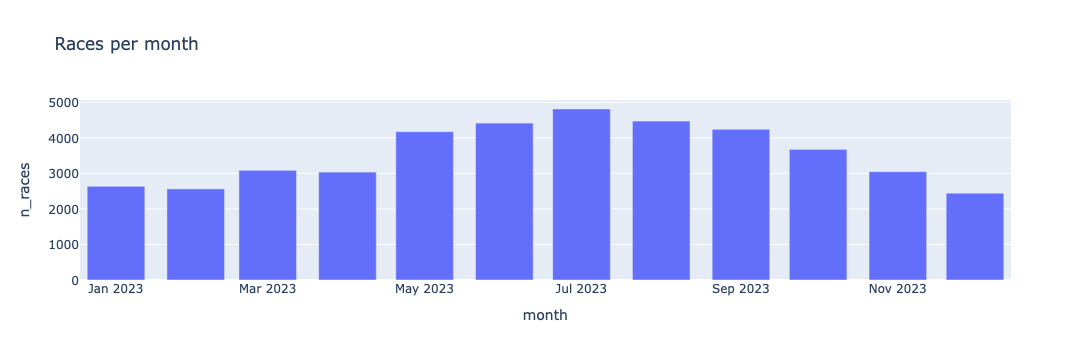

In [11]:
races_per_month = (
    results.unique(subset=["race_id"])
    .with_columns(month=pl.col("race_date").str.to_date("%Y-%m-%d").dt.truncate("1mo"))
    .group_by("month")
    .agg(pl.len().alias("n_races"))
    .sort("month")
)
px.bar(races_per_month, x="month", y="n_races", title="Races per month")

## 2. Grain and key validation

Expected grains:
- `results`, `entries` → one row per `(race_id, horse_name)`
- `past_performances` → one row per `(race_id, horse_name, pp_index)`
- `workouts` → many rows per `(race_id, horse_name)`

In [12]:
def grain_check(df: pl.DataFrame, keys: list[str], name: str) -> dict:
    n = len(df)
    n_unique = df.select(keys).n_unique()
    return {
        "table": name,
        "keys": "+".join(keys),
        "rows": n,
        "unique_keys": n_unique,
        "dupes": n - n_unique,
    }


checks = [
    grain_check(results, ["race_id", "horse_name"], "results"),
    grain_check(entries, ["race_id", "horse_name"], "entries"),
    grain_check(pps, ["race_id", "horse_name", "pp_index"], "past_performances"),
    # track_codes: track_id alone is NOT unique — the same 3-letter code is reused
    # across countries. The natural key is (country, track_id).
    grain_check(tracks, ["track_id"], "track_codes (track_id only)"),
    grain_check(tracks, ["country", "track_id"], "track_codes (country+track_id)"),
]
pl.DataFrame(checks)

table,keys,rows,unique_keys,dupes
str,str,i64,i64,i64
"""results""","""race_id+horse_name""",318702,318702,0
"""entries""","""race_id+horse_name""",472633,472633,0
"""past_performances""","""race_id+horse_name+pp_index""",3469904,3469904,0
"""track_codes (track_id only)""","""track_id""",233,233,0
"""track_codes (country+track_id)""","""country+track_id""",233,233,0


In [13]:
# Race-level overlap between entries and results
races_entries = set(entries["race_id"].unique().to_list())
races_results = set(results["race_id"].unique().to_list())
{
    "races_in_entries": len(races_entries),
    "races_in_results": len(races_results),
    "in_both": len(races_entries & races_results),
    "entries_only": len(races_entries - races_results),
    "results_only": len(races_results - races_entries),
}

{'races_in_entries': 53279,
 'races_in_results': 42618,
 'in_both': 42618,
 'entries_only': 10661,
 'results_only': 0}

## 3. Join validation

The training table will be `entries ⋈ results` on `(race_id, horse_name)`. Anything that doesn't join is either a scratch (entered but didn't run) or a name-normalization mismatch.

In [14]:
# Restrict to races present in both before measuring per-horse join rate
common_races = races_entries & races_results
e = entries.filter(pl.col("race_id").is_in(common_races))
r = results.filter(pl.col("race_id").is_in(common_races))

joined = e.join(
    r.select("race_id", "horse_name", "official_finish"),
    on=["race_id", "horse_name"],
    how="left",
)
n_total = len(joined)
n_matched = joined["official_finish"].is_not_null().sum()
{
    "entries_in_common_races": n_total,
    "matched_to_results": n_matched,
    "match_rate": round(n_matched / n_total, 4),
    "unmatched (likely scratches)": n_total - n_matched,
}

{'entries_in_common_races': 360524,
 'matched_to_results': 315798,
 'match_rate': 0.8759,
 'unmatched (likely scratches)': 44726}

In [15]:
# Past performance count per (race_id, horse_name) — how much history per runner?
pp_counts = (
    pps.group_by(["race_id", "horse_name"])
    .agg(pl.col("pp_index").max().alias("max_pp"), pl.len().alias("n_pps"))
)

# Bucket and join back to entries to see how many runners have how many PPs
pp_per_runner = (
    e.select("race_id", "horse_name")
    .join(pp_counts, on=["race_id", "horse_name"], how="left")
    .with_columns(n_pps=pl.col("n_pps").fill_null(0))
    .with_columns(
        bucket=pl.when(pl.col("n_pps") == 0)
        .then(pl.lit("0"))
        .when(pl.col("n_pps") <= 3)
        .then(pl.lit("1-3"))
        .when(pl.col("n_pps") <= 5)
        .then(pl.lit("4-5"))
        .when(pl.col("n_pps") <= 10)
        .then(pl.lit("6-10"))
        .otherwise(pl.lit("11+"))
    )
)
pp_per_runner.group_by("bucket").agg(pl.len().alias("n_runners")).sort("bucket")

bucket,n_runners
str,u32
"""0""",22362
"""1-3""",59059
"""11+""",75
"""4-5""",33372
"""6-10""",245656


In [16]:
# Workout coverage per runner
wo_counts = (
    workouts.group_by(["race_id", "horse_name"]).agg(pl.len().alias("n_workouts"))
)
wo_per_runner = (
    e.select("race_id", "horse_name")
    .join(wo_counts, on=["race_id", "horse_name"], how="left")
    .with_columns(n_workouts=pl.col("n_workouts").fill_null(0))
)
{
    "runners": len(wo_per_runner),
    "with_any_workout": (wo_per_runner["n_workouts"] > 0).sum(),
    "coverage": round((wo_per_runner["n_workouts"] > 0).mean(), 4),
    "median_workouts": wo_per_runner["n_workouts"].median(),
}

{'runners': 360524,
 'with_any_workout': 304320,
 'coverage': 0.8441,
 'median_workouts': 3.0}

## 4. Target variable: `official_finish`

In [17]:
# Distribution of finish positions (top of head, plus null/missing count)
results.group_by("official_finish").agg(pl.len().alias("n")).sort("official_finish")

official_finish,n
i64,u32
1,42732
2,42644
3,42584
4,42458
5,41280
6,36715
7,28283
8,19428
9,12160


In [18]:
# Field size: how many runners per race actually finished
field_sizes = (
    results.filter(pl.col("official_finish").is_not_null())
    .group_by("race_id")
    .agg(pl.len().alias("n_finishers"))
)
field_sizes.describe()

statistic,race_id,n_finishers
str,str,f64
"""count""","""42618""",42618.0
"""null_count""","""0""",0.0
"""mean""",null,7.478108
"""std""",null,1.865154
"""min""","""2023-01-01_AQU_R1""",2.0
"""25%""",null,6.0
"""50%""",null,7.0
"""75%""",null,9.0
"""max""","""2023-12-31_TAM_R9""",18.0


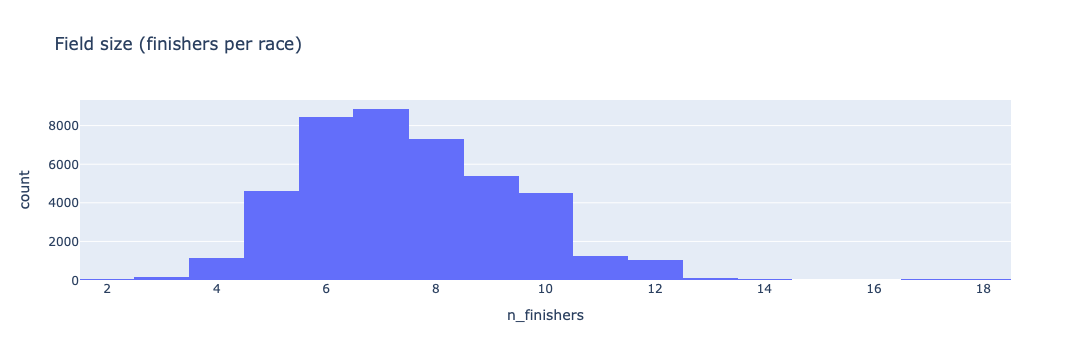

In [19]:
px.histogram(field_sizes, x="n_finishers", nbins=20, title="Field size (finishers per race)")

In [20]:
# Dead heats: more than one finisher with official_finish == 1 in the same race
dead_heats = (
    results.filter(pl.col("official_finish") == 1)
    .group_by("race_id")
    .agg(pl.len().alias("n_winners"))
    .filter(pl.col("n_winners") > 1)
)
{
    "races_with_dead_heat_for_win": len(dead_heats),
    "max_winners_in_one_race": dead_heats["n_winners"].max() if len(dead_heats) else 0,
}

{'races_with_dead_heat_for_win': 114, 'max_winners_in_one_race': 3}

In [21]:
# dh_dq_flags – what's encoded here?
results.group_by("dh_dq_flags").agg(pl.len().alias("n")).sort("n", descending=True).head(20)

dh_dq_flags,n
str,u32
null,315834
"""dh""",1505
"""dq""",1349
"""dhdq""",14


## 5. Candidate feature sanity checks

In [22]:
# dollar_odds (final tote odds) — distribution and missingness
results.select(
    pl.col("dollar_odds").is_null().mean().alias("null_rate"),
    pl.col("dollar_odds").min().alias("min"),
    pl.col("dollar_odds").quantile(0.5).alias("median"),
    pl.col("dollar_odds").quantile(0.95).alias("p95"),
    pl.col("dollar_odds").max().alias("max"),
)

null_rate,min,median,p95,max
f64,f64,f64,f64,f64
0.0,0.0,7.4,48.7,420.8


In [23]:
# Implied probability sum per race — should land around 1.15-1.30 with track takeout.
# dollar_odds is *to-1* (e.g. 5.0 means 5/1), so payoff per $1 = odds + 1, implied prob = 1/(odds+1)
implied = (
    results.filter(pl.col("dollar_odds").is_not_null() & (pl.col("dollar_odds") >= 0))
    .with_columns(implied=1 / (pl.col("dollar_odds") + 1))
    .group_by("race_id")
    .agg(pl.col("implied").sum().alias("book_sum"), pl.len().alias("n"))
)
implied.select(
    pl.col("book_sum").quantile(0.05).alias("p05"),
    pl.col("book_sum").median().alias("median"),
    pl.col("book_sum").mean().alias("mean"),
    pl.col("book_sum").quantile(0.95).alias("p95"),
)

p05,median,mean,p95
f64,f64,f64,f64
1.184223,1.225887,1.25957,1.347959


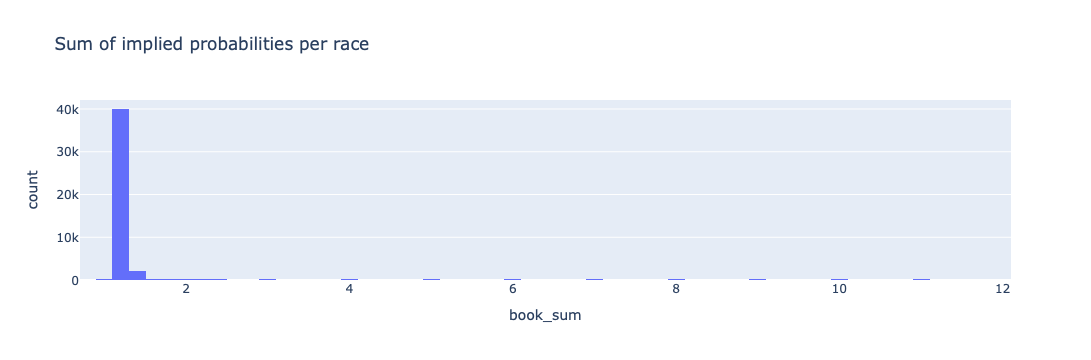

In [24]:
px.histogram(implied, x="book_sum", nbins=60, title="Sum of implied probabilities per race")

In [25]:
# speed_rating in results — null rate and distribution
results.select(
    pl.col("speed_rating").is_null().mean().alias("null_rate"),
    pl.col("speed_rating").min().alias("min"),
    pl.col("speed_rating").quantile(0.5).alias("median"),
    pl.col("speed_rating").quantile(0.95).alias("p95"),
    pl.col("speed_rating").max().alias("max"),
)

null_rate,min,median,p95,max
f64,i64,f64,f64,i64
0.0,0,63.0,92.0,126


In [26]:
# pp_speed_figure availability across the most-recent N PPs
(
    pps.filter(pl.col("pp_index") <= 5)
    .group_by("pp_index")
    .agg(
        pl.len().alias("n_rows"),
        pl.col("pp_speed_figure").is_not_null().mean().alias("speed_fig_coverage"),
        pl.col("pp_speed_figure").median().alias("median_speed"),
    )
    .sort("pp_index")
)

pp_index,n_rows,speed_fig_coverage,median_speed
i64,u32,f64,f64
1,445860,1.0,580.0
2,420376,1.0,580.0
3,395960,1.0,580.0
4,373053,1.0,590.0
5,351585,1.0,590.0


In [27]:
# Morning line vs final tote odds — sanity check correlation
ml_vs_final = (
    entries.select("race_id", "horse_name", "morning_line_decimal")
    .join(
        results.select("race_id", "horse_name", "dollar_odds"),
        on=["race_id", "horse_name"],
        how="inner",
    )
    .filter(
        pl.col("morning_line_decimal").is_not_null()
        & pl.col("dollar_odds").is_not_null()
    )
)
{
    "n": len(ml_vs_final),
    "corr": ml_vs_final.select(
        pl.corr("morning_line_decimal", "dollar_odds")
    ).item(),
}

{'n': 314953, 'corr': 0.7023462946424934}

In [28]:
# How well does the favorite (lowest dollar_odds) actually win?
fav_win = (
    results.filter(pl.col("dollar_odds").is_not_null())
    .with_columns(
        rank_by_odds=pl.col("dollar_odds").rank("ordinal").over("race_id"),
    )
    .filter(pl.col("rank_by_odds") == 1)
    .select(
        n_races=pl.len(),
        fav_win_rate=(pl.col("official_finish") == 1).mean(),
        avg_fav_odds=pl.col("dollar_odds").mean(),
    )
)
fav_win

n_races,fav_win_rate,avg_fav_odds
u32,f64,f64
42618,0.383125,1.422657


## 6. Takeaways

_Fill in after running the cells above. Bullet the things that affect feature engineering:_

- **Modeling grain**: most likely `(race_id, horse_name)` from `entries` left-joined to `results` (so scratches show up as null target and get filtered out for training).
- **Target**: `official_finish == 1`. Decide how to handle dead heats and DQs.
- **Date split**: only one season available — split by date within 2023 (e.g., last 2 months as holdout).
- **Feature columns confirmed usable**: …
- **Columns to drop / treat as missing-heavy**: …
- **Open questions**: …